In [1]:
import timm
import os
import cv2
import joblib
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision.models import ResNet50_Weights
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, confusion_matrix, roc_curve, auc, recall_score, precision_recall_curve, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import time


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
class CTDataset(Dataset):
    def __init__(self, image_paths, labels, image_size=256, augment=False, use_clahe=False):
        self.image_paths = image_paths
        self.labels = labels
        self.image_size = image_size
        self.augment = augment
        self.use_clahe = use_clahe

        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

        self.clahe = cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8, 8)
        )

    def __len__(self):
        return len(self.image_paths)

    def apply_clahe(self, img):
        img_u8 = (img * 255.0).clip(0, 255).astype(np.uint8)
        img_u8 = self.clahe.apply(img_u8)
        return img_u8.astype(np.float32) / 255.0

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        label = self.labels[idx]

        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

        if img is None:
            raise FileNotFoundError(f"Could not read image: {path}")

        if img.ndim == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        img = cv2.resize(
            img,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_AREA
        )

        img = img.astype(np.float32)

        if img.max() > 255:
            img = img / 65535.0
        else:
            img = img / 255.0

        if self.use_clahe:
            img = self.apply_clahe(img)

        if self.augment:
            if np.random.rand() < 0.5:
                img = np.fliplr(img).copy()

            if np.random.rand() < 0.5:
                angle = np.random.uniform(-10, 10)
                M = cv2.getRotationMatrix2D(
                    (self.image_size // 2, self.image_size // 2),
                    angle,
                    1.0
                )
                img = cv2.warpAffine(
                    img,
                    M,
                    (self.image_size, self.image_size),
                    borderMode=cv2.BORDER_REFLECT
                )

            if np.random.rand() < 0.5:
                alpha = np.random.uniform(0.9, 1.1)
                beta = np.random.uniform(-0.05, 0.05)
                img = np.clip(alpha * img + beta, 0, 1)

            if np.random.rand() < 0.3:
                noise = np.random.normal(0, 0.02, img.shape).astype(np.float32)
                img = np.clip(img + noise, 0, 1)

        img = torch.from_numpy(img.astype(np.float32)).unsqueeze(0)
        img = img.repeat(3, 1, 1)

        img = (img - self.mean) / self.std

        label = torch.tensor(label, dtype=torch.long)

        return img, label

In [4]:
train_dir = r"C:\Users\rgzep\Documents\IP data\data_png_wholeslice_lung256_processed\Centre10_split\train"
val_dir   = r"C:\Users\rgzep\Documents\IP data\data_png_wholeslice_lung256_processed\Centre10_split\val"
test_dir  = r"C:\Users\rgzep\Documents\IP data\data_png_wholeslice_lung256_processed\Centre10_split\test"

img_size = 256
batch_size = 16
dropout_rate = 0.6

In [5]:
train_base = ImageFolder(train_dir)
val_base = ImageFolder(val_dir)
test_base = ImageFolder(test_dir)

train_paths = [s[0] for s in train_base.samples]
train_labels = [s[1] for s in train_base.samples]

val_paths = [s[0] for s in val_base.samples]
val_labels = [s[1] for s in val_base.samples]

test_paths = [s[0] for s in test_base.samples]
test_labels = [s[1] for s in test_base.samples]

class_names = train_base.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Classes: ['no_nodule', 'nodule']
Train: 4050
Val: 860
Test: 890


In [6]:
train_data = CTDataset(train_paths, train_labels, image_size=img_size, augment=True)
val_data   = CTDataset(val_paths, val_labels, image_size=img_size, augment=False)
test_data  = CTDataset(test_paths, test_labels, image_size=img_size, augment=False)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

In [7]:
loaded_model = models.resnet50(weights=None)
loaded_model.fc = nn.Sequential(
    nn.Dropout(dropout_rate),
    nn.Linear(loaded_model.fc.in_features, num_classes)
)

loaded_model.load_state_dict(torch.load("saved_models/resnet50_best_sen.pth", map_location=device))
loaded_model = loaded_model.to(device)
loaded_model.eval()

C:\Users\rgzep\AppData\Local\Temp\ipykernel_16112\1234652072.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load("saved_models/resnet

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [8]:
class ResNetSwinHybrid(nn.Module):
    def __init__(self, trained_resnet, num_classes=2):
        super().__init__()

        # ResNet50 branch
        self.resnet_features = nn.Sequential(*list(trained_resnet.children())[:-2])   

        for param in self.resnet_features.parameters():
            param.requires_grad = False

        self.resnet_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.resnet_proj = nn.Linear(2048, 512)

        # Swin branch
        self.swin = timm.create_model("swinv2_tiny_window8_256", pretrained=True, num_classes=0)
        self.swin_proj = nn.Linear(self.swin.num_features, 512)

        # Fusion head
        self.classifier = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # ResNet branch
        r = self.resnet_features(x)
        r = self.resnet_pool(r).flatten(1)
        r = self.resnet_proj(r)

        # Swin branch
        s = self.swin(x)
        s = self.swin_proj(s)

        # Fusion
        fused = torch.cat([r, s], dim=1)
        out = self.classifier(fused)
        return out

model = ResNetSwinHybrid(trained_resnet=loaded_model, num_classes=num_classes).to(device)
print(model)

ResNetSwinHybrid(
  (resnet_features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
         

In [9]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    y_true, y_pred, y_prob = [], [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

        probs = torch.softmax(out, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    y_prob = np.array(y_prob)

    metrics = compute_metrics(y_true, y_pred, y_prob)

    return avg_loss, metrics, y_true, y_pred, y_prob

In [10]:
def compute_metrics(y_true, y_pred, y_prob=None):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "auc": 0.0
    }

    if y_prob is not None:
        try:
            metrics["auc"] = roc_auc_score(y_true, y_prob[:, 1])
        except:
            metrics["auc"] = 0.0

    return metrics

In [11]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item() * x.size(0)

            probs = torch.softmax(out, dim=1)
            preds = torch.argmax(probs, dim=1)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    y_prob = np.array(y_prob)

    metrics = compute_metrics(y_true, y_pred, y_prob)

    return avg_loss, metrics, y_true, y_pred, y_prob

In [12]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1
)

In [13]:
history = {
    "phase": [],
    "epoch": [],
    "epoch_time_sec": [],

    "train_loss": [],
    "val_loss": [],

    "train_acc": [],
    "val_acc": [],

    "train_precision": [],
    "val_precision": [],

    "train_recall": [],
    "val_recall": [],

    "train_f1": [],
    "val_f1": [],

    "train_auc": [],
    "val_auc": []
}

best_sen = 0.0
best_wts = copy.deepcopy(model.state_dict())

In [14]:
patience = 3
counter = 0

epochs = 15

for epoch in range(epochs):
    start_time = time.time()

    train_loss, train_metrics, _, _, _ = train_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_metrics, y_true, y_pred, y_prob = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step(val_metrics["recall"])

    epoch_time = time.time() - start_time

    history["phase"].append("train_val")
    history["epoch"].append(epoch + 1)
    history["epoch_time_sec"].append(epoch_time)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_metrics["accuracy"])
    history["val_acc"].append(val_metrics["accuracy"])

    history["train_precision"].append(train_metrics["precision"])
    history["val_precision"].append(val_metrics["precision"])

    history["train_recall"].append(train_metrics["recall"])
    history["val_recall"].append(val_metrics["recall"])

    history["train_f1"].append(train_metrics["f1"])
    history["val_f1"].append(val_metrics["f1"])

    history["train_auc"].append(train_metrics["auc"])
    history["val_auc"].append(val_metrics["auc"])

    if val_metrics["recall"] > best_sen:
        best_sen = val_metrics["recall"]
        best_wts = copy.deepcopy(model.state_dict())

        torch.save(
            model.state_dict(),
            "saved_models/resnet50_swin_best_sen.pth"
        )
        counter = 0
        print("Best model saved.")
    else:
        counter += 1
    
    if counter >= patience:
        print("Early stopping")
        break

        print("Best model saved.")

    print(f"\nEpoch {epoch+1}/{epochs} | Time: {epoch_time:.2f}s")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Train Acc : {train_metrics['accuracy']:.4f} | Val Acc : {val_metrics['accuracy']:.4f}")
    print(f"Train Precision: {train_metrics['precision']:.4f} | Val Precision: {val_metrics['precision']:.4f}")
    print(f"Train Macro Recall: {train_metrics['recall']:.4f} | Val Macro Recall: {val_metrics['recall']:.4f}")
    print(f"Train F1: {train_metrics['f1']:.4f} | Val F1: {val_metrics['f1']:.4f}")
    print(f"Train AUC: {train_metrics['auc']:.4f} | Val AUC: {val_metrics['auc']:.4f} \n")


Best model saved.

Epoch 1/15 | Time: 72.67s
Train Loss: 0.5139 | Val Loss: 0.4644
Train Acc : 0.7681 | Val Acc : 0.8430
Train Precision: 0.7415 | Val Precision: 0.8208
Train Macro Recall: 0.6107 | Val Macro Recall: 0.7562
Train F1: 0.6200 | Val F1: 0.7790
Train AUC: 0.8135 | Val AUC: 0.8767 

Best model saved.

Epoch 2/15 | Time: 75.48s
Train Loss: 0.4460 | Val Loss: 0.4347
Train Acc : 0.8353 | Val Acc : 0.8407
Train Precision: 0.8014 | Val Precision: 0.7981
Train Macro Recall: 0.7674 | Val Macro Recall: 0.7905
Train F1: 0.7813 | Val F1: 0.7941
Train AUC: 0.8880 | Val AUC: 0.8967 

Best model saved.

Epoch 3/15 | Time: 74.31s
Train Loss: 0.4081 | Val Loss: 0.5397
Train Acc : 0.8642 | Val Acc : 0.7895
Train Precision: 0.8388 | Val Precision: 0.7548
Train Macro Recall: 0.8089 | Val Macro Recall: 0.8136
Train F1: 0.8218 | Val F1: 0.7644
Train AUC: 0.9200 | Val AUC: 0.9075 


Epoch 4/15 | Time: 74.45s
Train Loss: 0.3740 | Val Loss: 0.4669
Train Acc : 0.8916 | Val Acc : 0.8384
Train Precis

In [15]:
model.load_state_dict(best_wts)
print("Best Validation macro recall", best_sen)

Best Validation macro recall 0.8135610766045549


In [16]:
test_loss, test_metrics, y_true, y_pred, y_prob = evaluate(
    model, test_loader, criterion, device
)

print("\nTest Results")
print("Test Loss       :", round(test_loss, 4))
print("Accuracy        :", round(test_metrics["accuracy"], 4))
print("Macro Precision :", round(test_metrics["precision"], 4))
print("Macro Recall    :", round(test_metrics["recall"], 4))
print("Macro F1        :", round(test_metrics["f1"], 4))
print("AUC             :", round(test_metrics["auc"], 4))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


Test Results
Test Loss       : 0.6412
Accuracy        : 0.7427
Macro Precision : 0.7062
Macro Recall    : 0.7443
Macro F1        : 0.7128
AUC             : 0.8334

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.53      0.75      0.62       250
      nodule       0.88      0.74      0.81       640

    accuracy                           0.74       890
   macro avg       0.71      0.74      0.71       890
weighted avg       0.78      0.74      0.75       890


Confusion Matrix:
[[187  63]
 [166 474]]


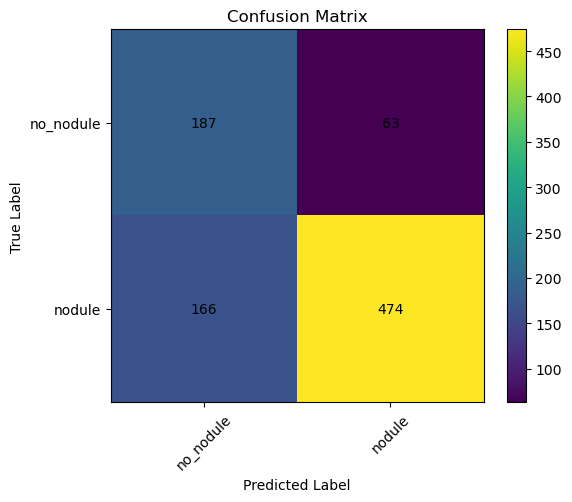

In [17]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

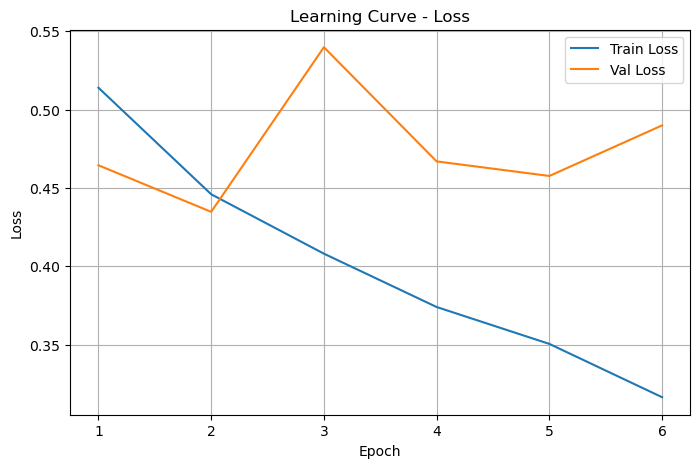

In [18]:
epochs_ran = range(1, len(history["epoch"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_loss"], label="Train Loss")
plt.plot(epochs_ran, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve - Loss")
plt.legend()
plt.grid(True)
plt.show()

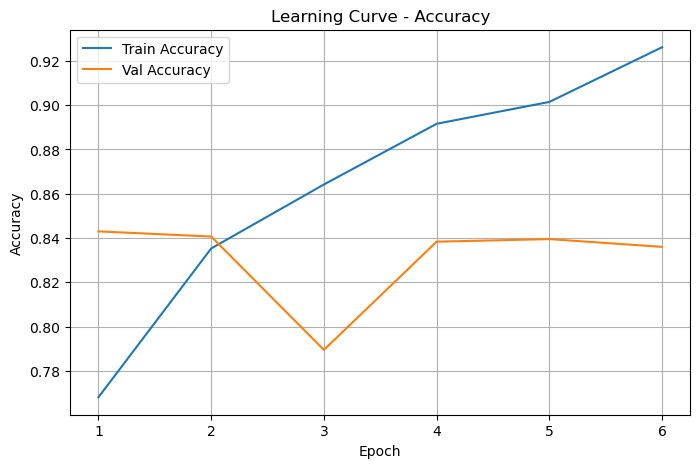

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_ran, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Accuracy")
plt.legend()
plt.grid(True)
plt.show()

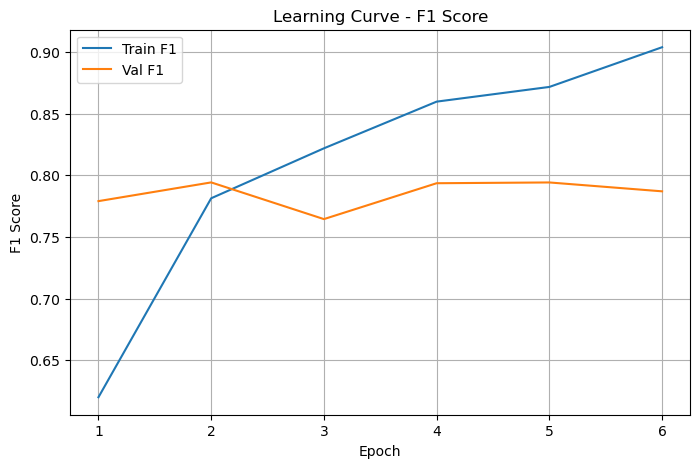

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_f1"], label="Train F1")
plt.plot(epochs_ran, history["val_f1"], label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Learning Curve - F1 Score")
plt.legend()
plt.grid(True)
plt.show()

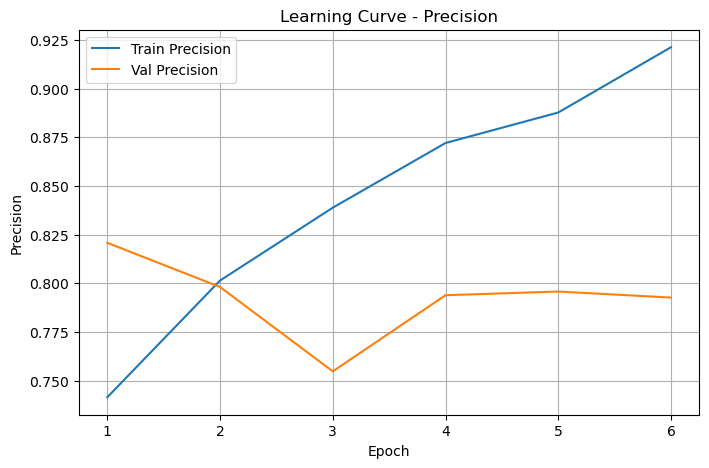

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_precision"], label="Train Precision")
plt.plot(epochs_ran, history["val_precision"], label="Val Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Learning Curve - Precision")
plt.legend()
plt.grid(True)
plt.show()

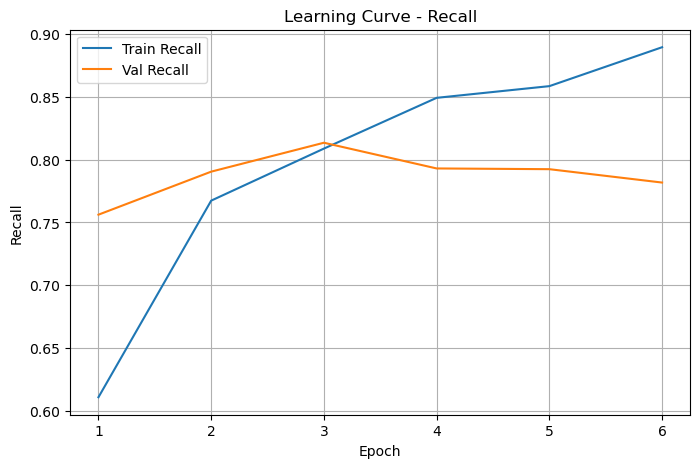

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_recall"], label="Train Recall")
plt.plot(epochs_ran, history["val_recall"], label="Val Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Learning Curve - Recall")
plt.legend()
plt.grid(True)
plt.show()

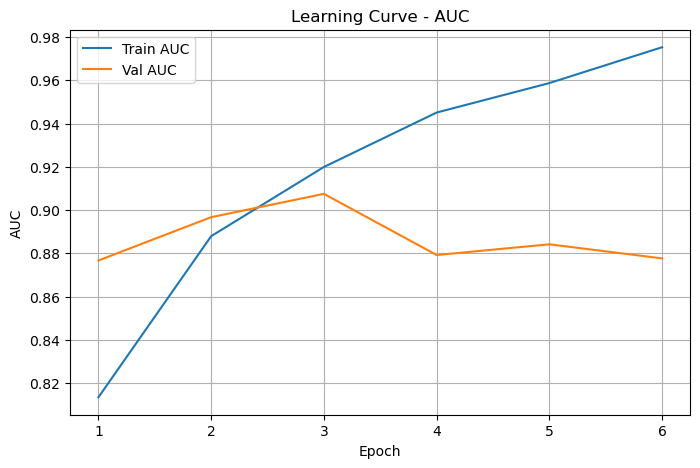

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_auc"], label="Train AUC")
plt.plot(epochs_ran, history["val_auc"], label="Val AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Learning Curve - AUC")
plt.legend()
plt.grid(True)
plt.show()

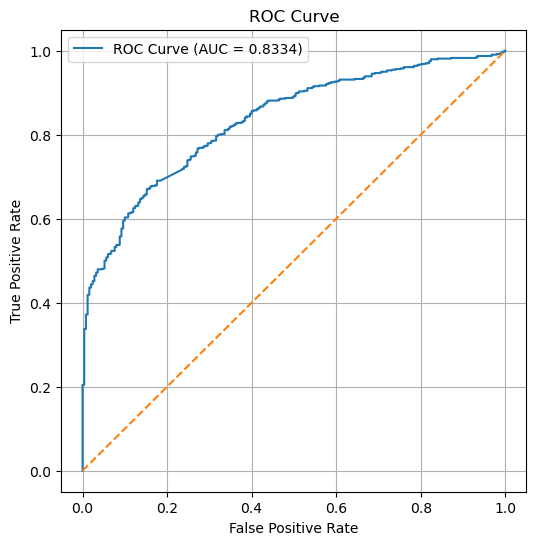

In [24]:
fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {test_metrics['auc']:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()